# MCZA018 – Processamento Digital de Imagens
## Laboratório 8 – Segmentação Morfológica Watershed

**Autores:**
- Igor Ladeia de Freitas (RA 11201922180)
- Gustavo Fernandes do Nascimento (RA 11202021700)
- Ryan Lucas da Silva (RA 11202522362)
- Eduardo Yukio Makita (RA 11202020221)

**Data de realização:** Abril/2026  
**Data de publicação:** Abril/2026

---
## Introdução

Neste laboratório estudamos a **Segmentação Morfológica Watershed**. A metáfora do watershed trata a imagem como um relevo topográfico: intensidades representam altitudes e o algoritmo simula o alagamento a partir de mínimos locais, formando bacias que correspondem às regiões segmentadas.

**Pipeline:**
1. Pré-processamento / Remoção de ruídos
2. Limiarização (Otsu)
3. Operações Morfológicas
4. Transformada de Distância
5. Rotulação / Marcadores
6. Watershed
7. Pós-processamento e visualização

## 0. Importação de Bibliotecas

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

print(f'OpenCV: {cv2.__version__}')
print(f'NumPy:  {np.__version__}')

OpenCV: 4.13.0
NumPy:  2.4.4


## Funções Auxiliares

In [3]:
def load_image_from_url(url, filename):
    raw_url = url.replace('https://github.com/', 'https://raw.githubusercontent.com/').replace('/blob/', '/')
    if not os.path.exists(filename):
        urllib.request.urlretrieve(raw_url, filename)
        print(f'Download: {filename}')
    img = cv2.imread(filename)
    if img is None:
        raise FileNotFoundError(f'Falha ao carregar: {filename}')
    return img

def bgr_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_images(images, titles, figsize=(18,5)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images)==1: axes=[axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img if len(img.shape)==2 else bgr_rgb(img), cmap='gray' if len(img.shape)==2 else None)
        ax.set_title(title, fontsize=10); ax.axis('off')
    plt.tight_layout(); plt.show()

## 1. Carregamento das Imagens

Download: imagem_grupo.png
Download: imagem_grupo_avatar.png
Download: frame_projeto.png


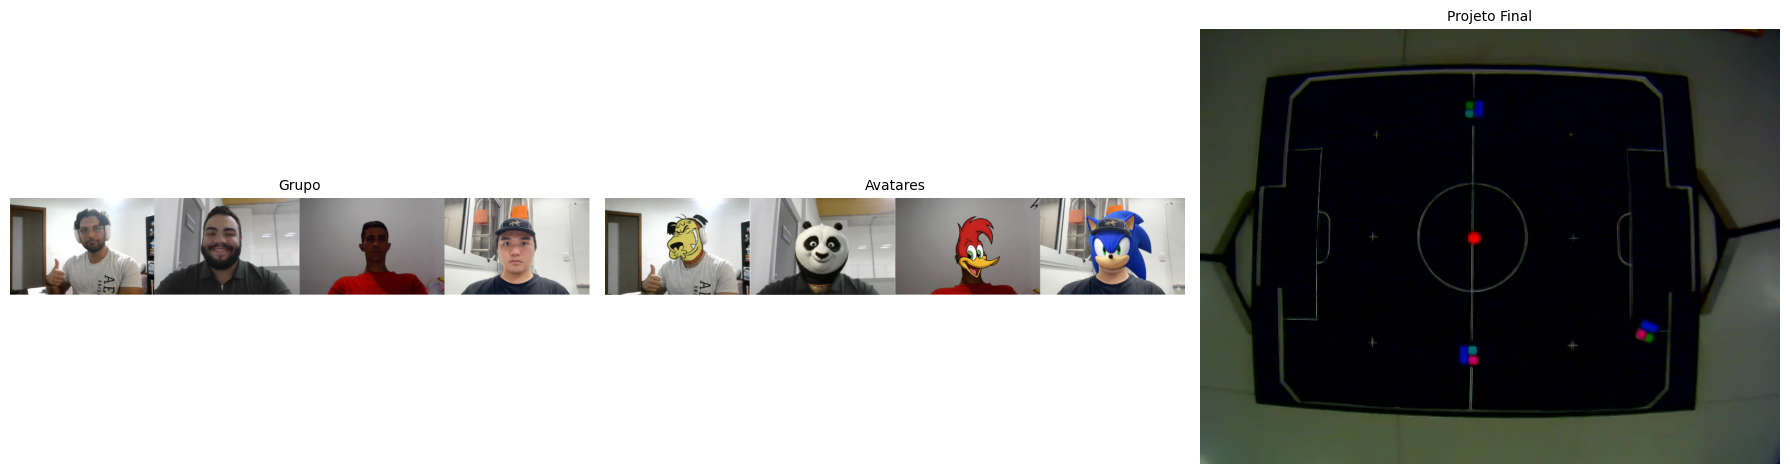

In [4]:
BASE = 'https://github.com/IgorLadeia/Processamento_Digital_Imagens/blob/main/imagens/'

img_grupo   = load_image_from_url(BASE + 'Lab2/imagem_grupo.png',        'imagem_grupo.png')
img_avatar  = load_image_from_url(BASE + 'Lab2/imagem_grupo_avatar.png', 'imagem_grupo_avatar.png')
img_projeto = load_image_from_url(BASE + 'frame_02820.png',              'frame_projeto.png')

show_images([img_grupo, img_avatar, img_projeto], ['Grupo', 'Avatares', 'Projeto Final'])

---
## Atividade 3.a – Watershed Passo a Passo

### Função Principal do Pipeline

In [5]:
def watershed_pipeline(img_bgr, nome, blur_ksize=5, morph_ksize=3, dist_thresh_factor=0.4):
    """
    Pipeline completo de Segmentação Morfológica Watershed.
    Retorna dicionário com todas as etapas intermediárias.
    """
    R = {'original': img_bgr.copy()}

    # PASSO 1 – Escala de cinza
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    R['gray'] = gray

    # PASSO 2 – Remoção de ruídos
    # Gaussiano: suaviza ruído aditivo
    # Mediana:   remove ruído impulsivo (sal e pimenta)
    g = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    m = cv2.medianBlur(g, blur_ksize)
    R['blurred_gauss'] = g
    R['blurred_median'] = m

    # PASSO 3 – Limiarização de Otsu
    # Calcula automaticamente o limiar ótimo pelo histograma bimodal.
    # THRESH_BINARY_INV: objetos escuros ficam brancos (foreground).
    ret, thresh = cv2.threshold(m, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    R['thresh'] = thresh
    R['otsu_value'] = ret

    # PASSO 4 – Abertura Morfológica
    # Erosão + Dilatação: elimina pixels isolados sem alterar objetos maiores.
    kernel  = np.ones((morph_ksize, morph_ksize), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    R['opening'] = opening

    # PASSO 5 – Background seguro
    # Dilatação expande o foreground; região fora = definitivamente fundo.
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    R['sure_bg'] = sure_bg

    # PASSO 6 – Transformada de Distância
    # Distância euclidiana de cada pixel ao fundo mais próximo.
    # Picos = centros dos objetos (mais longe das bordas).
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
    R['dist_transform'] = dist

    # PASSO 7 – Foreground seguro (sementes/marcadores)
    # Pixels com distância > fator × máximo = definitivamente objeto.
    _, sure_fg = cv2.threshold(dist, dist_thresh_factor, 1.0, cv2.THRESH_BINARY)
    sure_fg = np.uint8(sure_fg * 255)
    R['sure_fg'] = sure_fg

    # PASSO 8 – Região desconhecida
    # Entre background e foreground seguros: o Watershed resolve aqui.
    unknown = cv2.subtract(sure_bg, sure_fg)
    R['unknown'] = unknown

    # PASSO 9 – Rotulação dos marcadores
    # Cada componente conexo recebe rótulo único.
    # +1: fundo fica com rótulo 1 (não 0); objetos começam em 2.
    # unknown → 0: indica ao Watershed que deve decidir essa região.
    num_labels, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    R['markers_before'] = markers.copy()
    R['num_labels'] = num_labels

    # PASSO 10 – Watershed
    # Expande as bacias a partir dos marcadores. Bordas recebem rótulo -1.
    markers_ws = cv2.watershed(img_bgr.copy(), markers)
    R['markers_ws'] = markers_ws

    # PASSO 11 – Resultado: bordas em vermelho
    result = img_bgr.copy()
    result[markers_ws == -1] = [0, 0, 255]
    R['img_result'] = result

    return R


def plot_pipeline(R, nome):
    steps = [
        ('original',       f'{nome} – Original'),
        ('gray',           'Escala de Cinza'),
        ('blurred_gauss',  'Filtro Gaussiano'),
        ('blurred_median', 'Filtro de Mediana'),
        ('thresh',         f'Limiarização Otsu (T={R["otsu_value"]:.0f})'),
        ('opening',        'Abertura Morfológica'),
        ('sure_bg',        'Background Seguro'),
        ('dist_transform', 'Transf. de Distância'),
        ('sure_fg',        'Foreground Seguro'),
        ('unknown',        'Região Desconhecida'),
        ('img_result',     'Resultado Watershed'),
    ]
    cols, rows = 4, 3
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
    axes = axes.flatten()
    for i, (key, title) in enumerate(steps):
        img = R[key]
        if len(img.shape)==2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(bgr_rgb(img))
        axes[i].set_title(title, fontsize=9); axes[i].axis('off')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.suptitle(f'Pipeline Watershed – {nome}', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

### 3.a.i – Segmentação da Imagem do Grupo

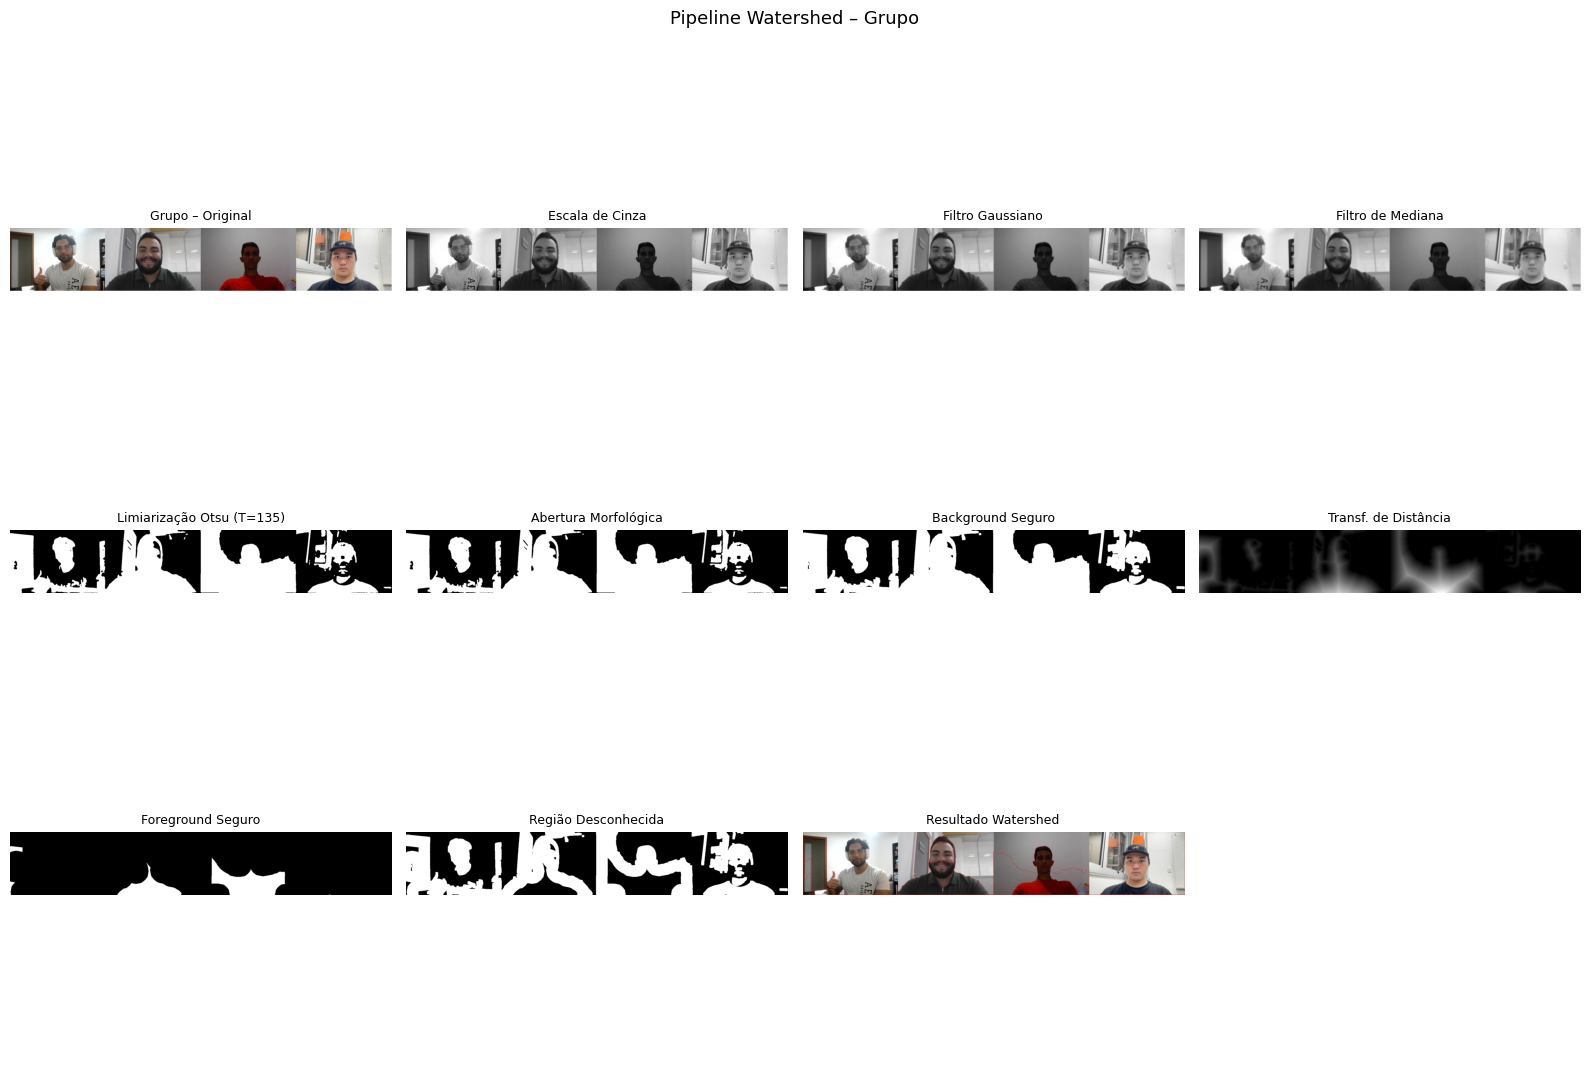

Limiar Otsu: 135
Regiões detectadas: 6


In [6]:
res_grupo = watershed_pipeline(img_grupo, 'Grupo', blur_ksize=7, morph_ksize=3, dist_thresh_factor=0.35)
plot_pipeline(res_grupo, 'Grupo')
print(f"Limiar Otsu: {res_grupo['otsu_value']:.0f}")
print(f"Regiões detectadas: {res_grupo['num_labels']}")

#### Análise – Imagem do Grupo

**Limiarização (Otsu):** Analisa o histograma da imagem suavizada e determina o limiar que minimiza a variância intra-classe. O `otsu_value` indica o ponto de separação bimodal entre fundo e pessoas.

**Transformada de Distância:** Os picos (regiões mais brilhantes) indicam os centros de cada pessoa — pixels mais distantes das bordas. O parâmetro `dist_thresh_factor=0.35` filtra apenas os picos mais significativos como marcadores.

**Rotulação:** Cada blob do foreground seguro recebe um rótulo único. Pessoas próximas ou se tocando podem ter seus blobs fundidos, resultando em um único marcador para duas pessoas — limitação clássica do Watershed clássico.

### 3.a.ii – Segmentação da Imagem dos Avatares

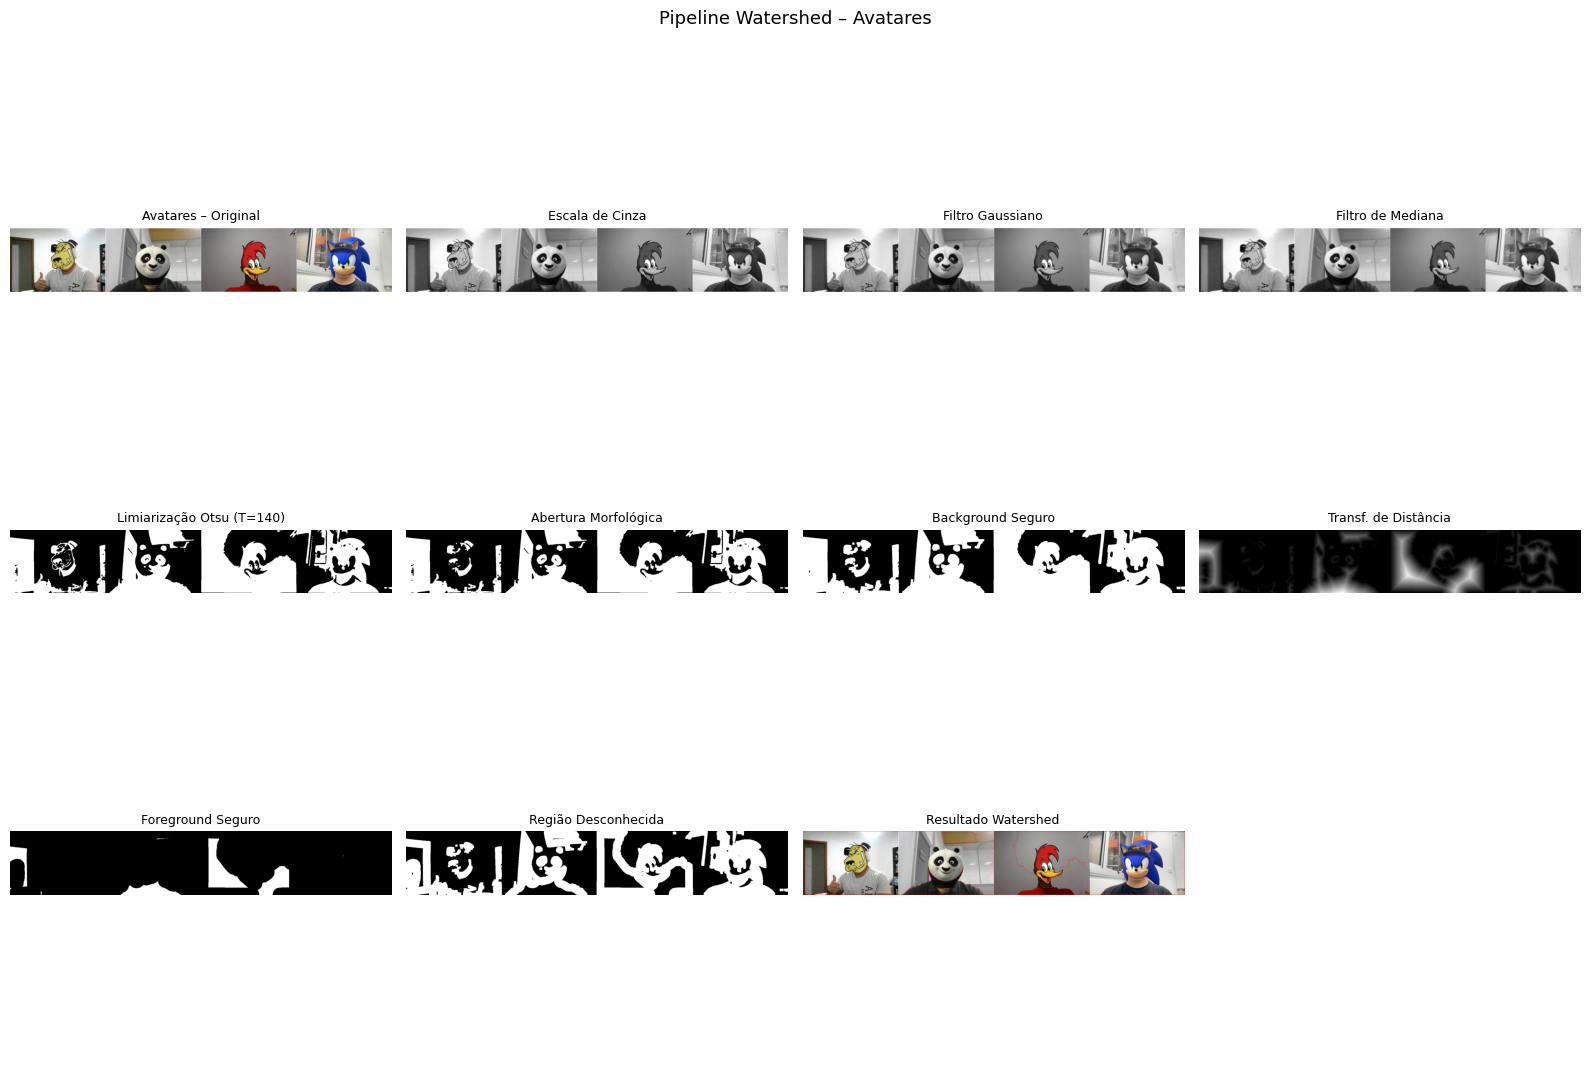

Limiar Otsu: 140
Regiões detectadas: 9


In [7]:
res_avatar = watershed_pipeline(img_avatar, 'Avatares', blur_ksize=5, morph_ksize=3, dist_thresh_factor=0.4)
plot_pipeline(res_avatar, 'Avatares')
print(f"Limiar Otsu: {res_avatar['otsu_value']:.0f}")
print(f"Regiões detectadas: {res_avatar['num_labels']}")

#### Análise – Imagem dos Avatares

**Limiarização:** Imagens de avatar têm fundo uniforme e cores saturadas, produzindo separação mais limpa. O Otsu encontra um limiar mais representativo do que em fotos reais.

**Transformada de Distância:** Contornos bem definidos resultam em picos mais pronunciados, gerando marcadores de maior qualidade e posicionados com mais precisão nos centros.

**Rotulação:** Espera-se número de rótulos próximo ao número de avatares. A qualidade é superior à foto real pelo maior contraste e bordas mais nítidas.

**Comparativo foto vs. avatar:** O Watershed performa melhor em imagens sintéticas — fotografias reais têm variação de iluminação, texturas complexas e transições suaves entre pessoas e fundo.

---
## Atividade 3.b – Contornos, Rótulos e Identificação

In [8]:
def watershed_labeled(img_bgr, R, labels_dict=None, font_scale=0.55, min_area=500):
    """
    Sobrepõe à imagem original: contornos coloridos, rótulos numéricos
    e nomes de cada segmento detectado.
    """
    markers_ws = R['markers_ws']
    out = img_bgr.copy()
    out[markers_ws == -1] = [0, 0, 255]  # bordas globais em vermelho

    palette = [
        (255,80,80),(80,255,80),(80,80,255),
        (255,230,0),(0,230,255),(230,0,230),
        (200,130,50),(50,200,130),(130,50,200)
    ]

    unique = np.unique(markers_ws)
    unique = unique[unique > 1]  # remove fundo(1) e borda(-1)
    valid = 0

    for lbl in unique:
        mask = np.uint8(markers_ws == lbl) * 255
        if np.sum(mask>0) < min_area: continue

        M = cv2.moments(mask)
        if M['m00'] == 0: continue
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])

        color = palette[valid % len(palette)]
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, color, 2)

        nome = labels_dict.get(int(lbl), f'Obj {lbl}') if labels_dict else f'Obj {lbl}'
        text = f'#{lbl} {nome}'

        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 2)
        overlay = out.copy()
        cv2.rectangle(overlay, (cx-4, cy-th-8), (cx+tw+4, cy+4), (0,0,0), -1)
        cv2.addWeighted(overlay, 0.55, out, 0.45, 0, out)
        cv2.putText(out, text, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale, (255,255,255), 2, cv2.LINE_AA)
        valid += 1

    return out

### 3.b.i – Resultado Rotulado – Grupo

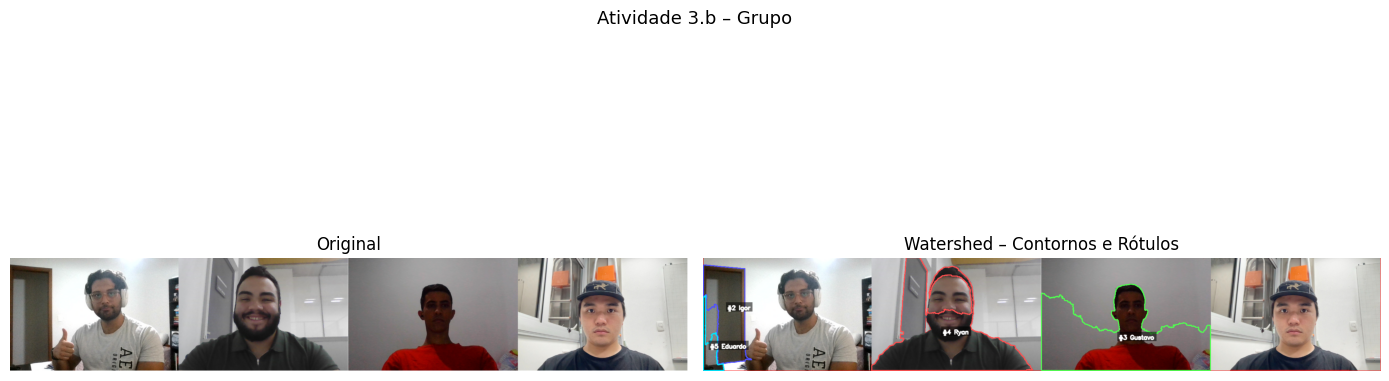

Salvo: resultado_grupo_rotulado.png


In [9]:
# Ajuste os IDs abaixo conforme o num_labels retornado para sua imagem
labels_grupo = {2:'Igor', 3:'Gustavo', 4:'Ryan', 5:'Eduardo'}

out_grupo = watershed_labeled(img_grupo, res_grupo, labels_dict=labels_grupo, min_area=2000)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bgr_rgb(img_grupo));  axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(bgr_rgb(out_grupo));  axes[1].set_title('Watershed – Contornos e Rótulos');  axes[1].axis('off')
plt.suptitle('Atividade 3.b – Grupo', fontsize=13)
plt.tight_layout(); plt.show()

cv2.imwrite('resultado_grupo_rotulado.png', out_grupo)
print('Salvo: resultado_grupo_rotulado.png')

### 3.b.ii – Resultado Rotulado – Avatares

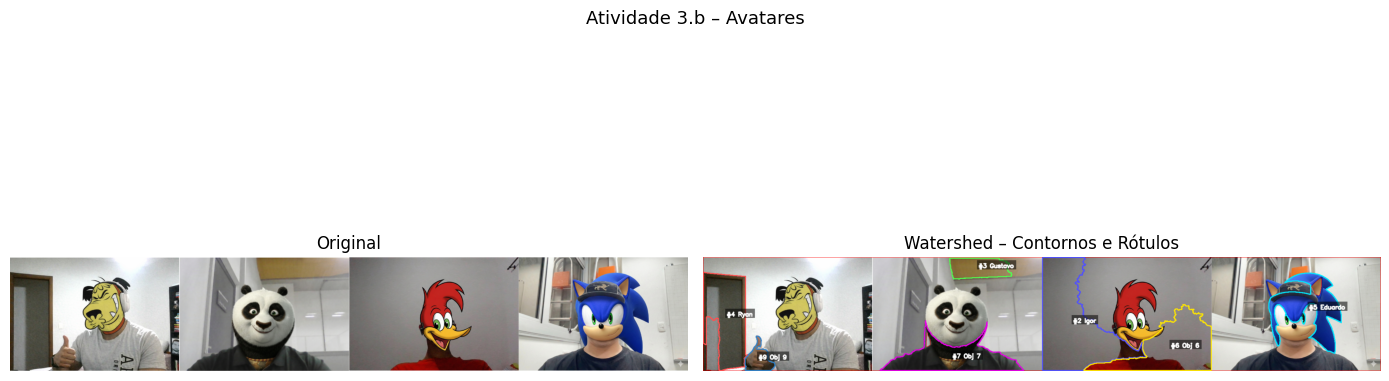

Salvo: resultado_avatar_rotulado.png


In [10]:
labels_avatar = {2:'Igor', 3:'Gustavo', 4:'Ryan', 5:'Eduardo'}

out_avatar = watershed_labeled(img_avatar, res_avatar, labels_dict=labels_avatar, min_area=1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bgr_rgb(img_avatar));  axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(bgr_rgb(out_avatar));  axes[1].set_title('Watershed – Contornos e Rótulos');  axes[1].axis('off')
plt.suptitle('Atividade 3.b – Avatares', fontsize=13)
plt.tight_layout(); plt.show()

cv2.imwrite('resultado_avatar_rotulado.png', out_avatar)
print('Salvo: resultado_avatar_rotulado.png')

---
## Atividade 3.c – Segmentação em Tempo Real com Webcam

In [11]:
def watershed_frame(frame, blur_ksize=7, morph_ksize=3, dist_thresh=0.35, min_area=3000):
    """Versão otimizada para tempo real: retorna frame com contornos sobrepostos."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.medianBlur(cv2.GaussianBlur(gray, (blur_ksize,blur_ksize), 0), blur_ksize)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel  = np.ones((morph_ksize,morph_ksize), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
    _, sure_fg = cv2.threshold(dist, dist_thresh, 1.0, cv2.THRESH_BINARY)
    sure_fg = np.uint8(sure_fg * 255)

    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown==255] = 0
    markers = cv2.watershed(frame, markers)

    out = frame.copy()
    out[markers==-1] = [0,0,255]

    colors = [(255,80,80),(80,255,80),(80,80,255),(255,255,0),(0,255,255),(255,0,255)]
    unique = np.unique(markers); unique = unique[unique>1]
    count = 0
    for idx, lbl in enumerate(unique):
        mask = np.uint8(markers==lbl)*255
        if np.sum(mask>0) < min_area: continue
        count += 1
        M = cv2.moments(mask)
        if M['m00']==0: continue
        cx, cy = int(M['m10']/M['m00']), int(M['m01']/M['m00'])
        color = colors[idx % len(colors)]
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, color, 2)
        cv2.putText(out, f'Pessoa {count}', (cx,cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)

    cv2.putText(out, f'Regioes: {count}', (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2, cv2.LINE_AA)
    return out


def run_webcam_watershed(output_file='video_watershed.avi', duration_sec=30, fps=10):
    """
    Captura webcam, aplica Watershed em tempo real e grava vídeo side-by-side.
    Pressione 'q' para encerrar.
    """
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print('ERRO: webcam não encontrada.'); return

    w, h = int(cap.get(3)), int(cap.get(4))
    writer = cv2.VideoWriter(output_file, cv2.VideoWriter_fourcc(*'XVID'), fps, (w*2, h))
    max_frames, frame_count = duration_sec*fps, 0
    print(f"Gravando '{output_file}' — pressione 'q' para sair.")

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break
        combined = np.hstack([frame, watershed_frame(frame)])
        writer.write(combined)
        cv2.imshow('Original | Watershed  (q=sair)', combined)
        if cv2.waitKey(1) & 0xFF == ord('q'): break
        frame_count += 1

    cap.release(); writer.release(); cv2.destroyAllWindows()
    print(f"Salvo: '{output_file}' ({frame_count} frames)")


# Para executar, descomente:
# run_webcam_watershed('video_watershed.avi', duration_sec=30, fps=10)

#### Análise dos Artefatos – Webcam

| Artefato | Causa | Mitigação |
|---|---|---|
| **Super-segmentação** | Sensibilidade a gradientes em texturas (cabelos, roupas) | Aumentar `dist_thresh_factor` |
| **Flickering** | Otsu recalcula limiar por frame; variações de luz alteram resultado | Usar limiar fixo ou média temporal |
| **Fusão de regiões** | Pessoas próximas geram blob único | Mais iterações de erosão morfológica |
| **Sensibilidade à luz** | Iluminação não uniforme cria gradientes artificiais | CLAHE como pré-processamento |
| **Latência** | Pipeline iterativo mais lento que filtros simples | Reduzir resolução; implementação GPU |
| **Bordas de frame** | Gradientes fortes nas extremidades geram marcadores falsos | Adicionar borda preta ao frame |

---
## Atividade 4.a – Watershed no Projeto Final

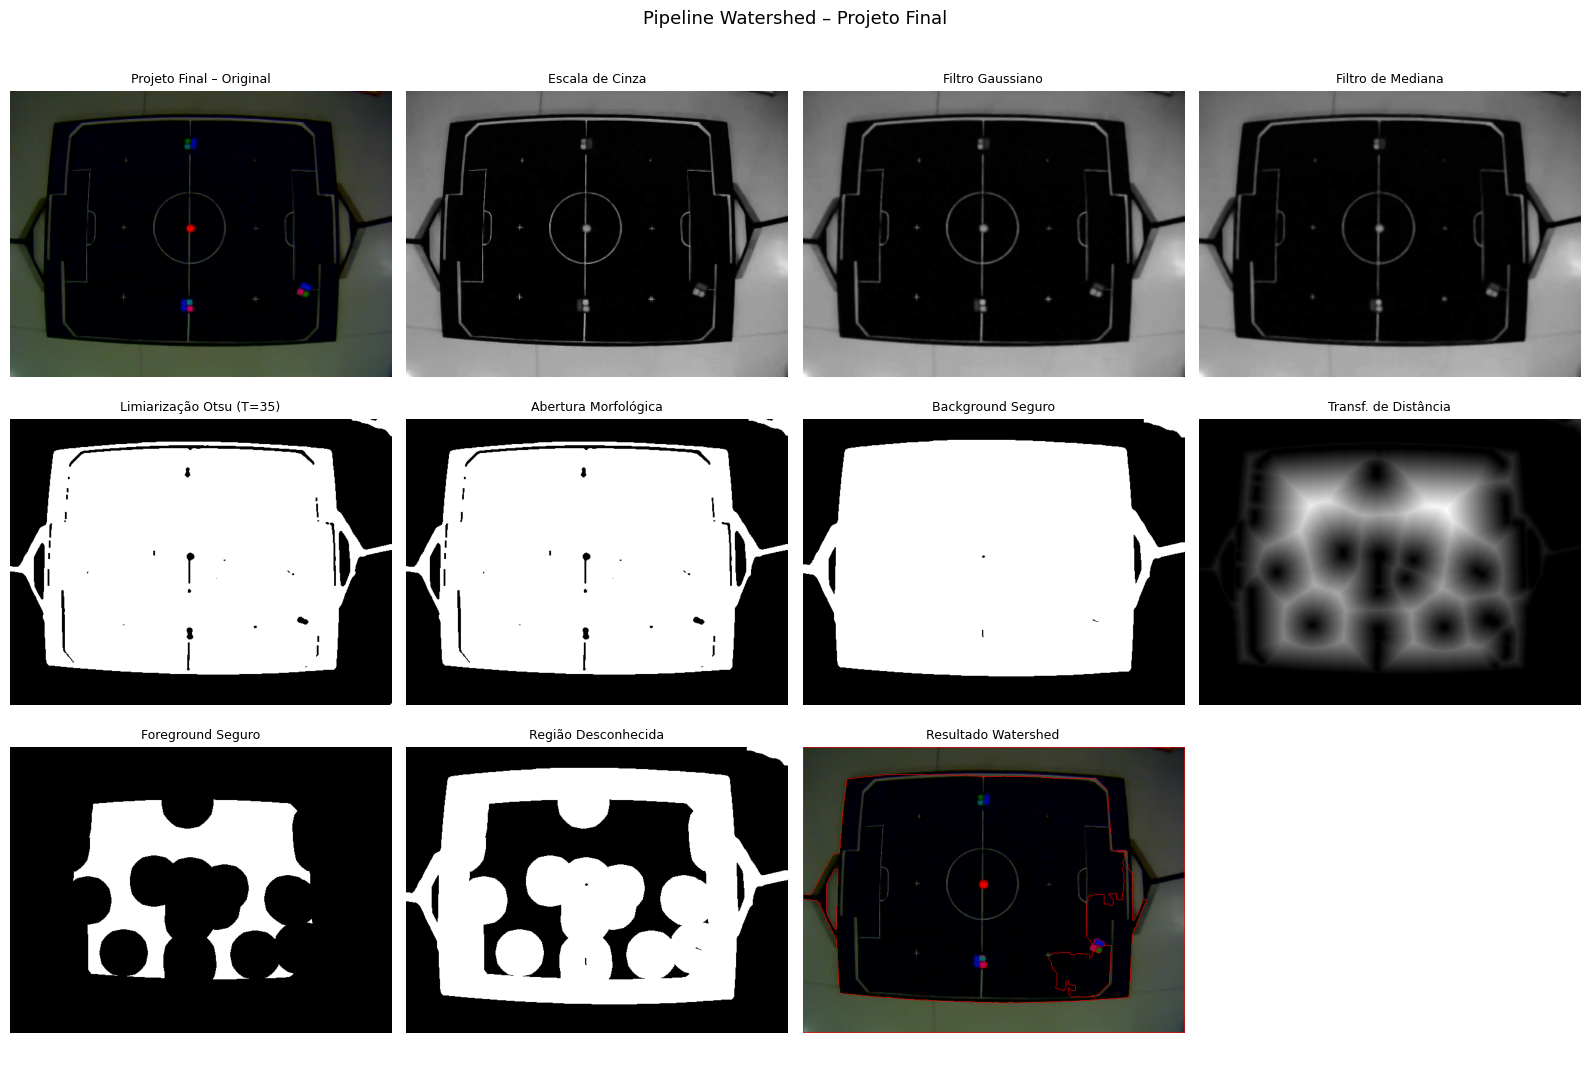

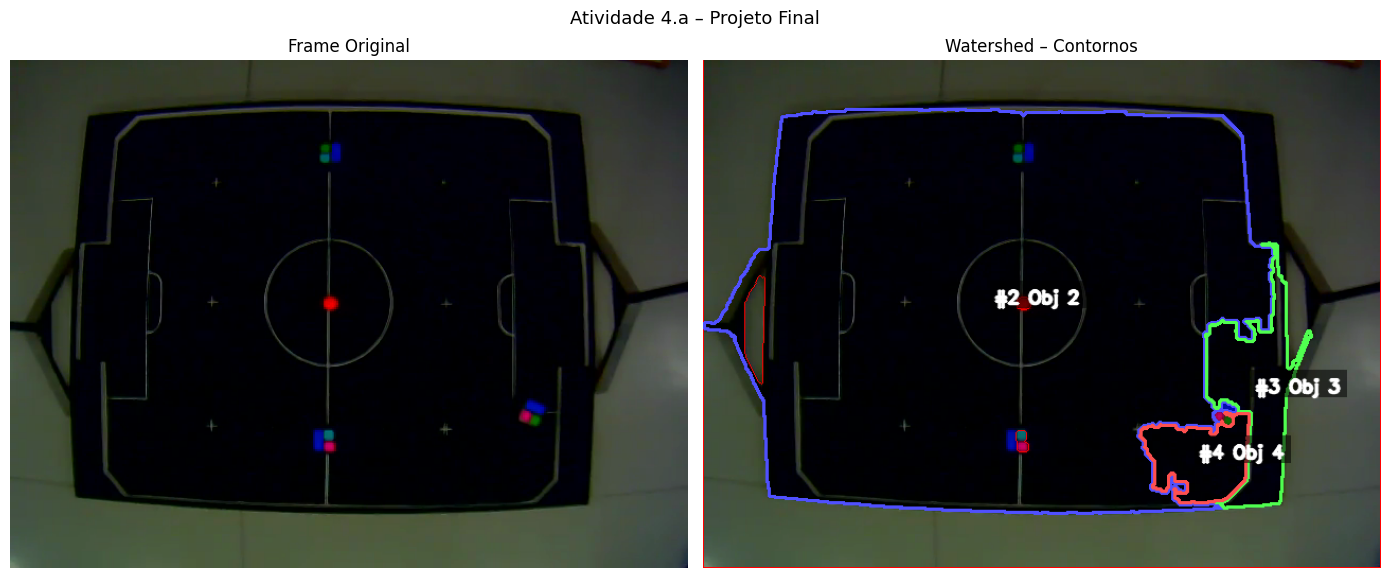

Salvo: resultado_projeto_watershed.png


In [12]:
res_projeto = watershed_pipeline(img_projeto, 'Projeto Final', blur_ksize=5, dist_thresh_factor=0.4)
plot_pipeline(res_projeto, 'Projeto Final')

out_projeto = watershed_labeled(img_projeto, res_projeto, min_area=1500)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bgr_rgb(img_projeto)); axes[0].set_title('Frame Original'); axes[0].axis('off')
axes[1].imshow(bgr_rgb(out_projeto)); axes[1].set_title('Watershed – Contornos'); axes[1].axis('off')
plt.suptitle('Atividade 4.a – Projeto Final', fontsize=13)
plt.tight_layout(); plt.show()

cv2.imwrite('resultado_projeto_watershed.png', out_projeto)
print('Salvo: resultado_projeto_watershed.png')

#### Objetivo no Projeto Final

A Segmentação Watershed é aplicada para **identificar e delimitar regiões de interesse** nos frames de vídeo do projeto, separando objetos/pessoas da cena para análise individual de cada região. A técnica é adequada por ser clássica (sem necessidade de dataset de treinamento), computacionalmente viável por frame, e poder ser combinada com rastreamento e classificação em etapas posteriores.

---
## Conclusões

- **Pipeline passo a passo:** A sequência pré-processamento → limiarização → morfologia → transformada de distância → marcadores → Watershed segmenta regiões de forma eficaz quando há contraste suficiente.
- **Foto vs. avatar:** Imagens sintéticas produzem resultados significativamente melhores devido a contornos nítidos e fundo uniforme.
- **Tempo real (webcam):** O Watershed clássico apresenta limitações importantes para aplicações de tempo real: flickering, super-segmentação e latência. Combinação com técnicas modernas de Deep Learning é recomendada para uso em produção.
- **Projeto final:** A técnica serve como base sólida para análise de regiões de interesse em vídeo.

---
## Referências

1. GONZALEZ, R. C. *Digital Image Processing*. 4. ed. Pearson, 2018. Chapter 10.
2. OpenCV. *Watershed Algorithm Tutorial*. https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html
3. OpenCV. *Image Thresholding*. https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
4. MALLICK, S. *Image Thresholding in OpenCV*. LearnOpenCV, 2015. https://learnopencv.com/opencv-threshold-python-cpp/